In [1]:
!pip install ultralytics opencv-python scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.8 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
DATASET_PATH = "/kaggle/input/datasets/amaritanshigupta/db-overlay-dataset"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
TEST_PATH  = os.path.join(DATASET_PATH, "test")
TEST_PATH="/kaggle/input/datasets/amaritanshigupta/db-overlay-dataset/db_overlay/test"
TRAIN_PATH="/kaggle/input/datasets/amaritanshigupta/db-overlay-dataset/db_overlay/train"
print("Train images:", len(os.listdir("/kaggle/input/datasets/amaritanshigupta/db-overlay-dataset/db_overlay/train")))
print("Test images:", len(os.listdir("/kaggle/input/datasets/amaritanshigupta/db-overlay-dataset/db_overlay/test")))

Train images: 80
Test images: 9


In [8]:
def preprocess_image(img_path):

    img = cv2.imread(img_path)

    img = cv2.resize(img,(640,640))

    green = img[:,:,1]

    clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))

    enhanced = clahe.apply(green)

    return img, green, enhanced

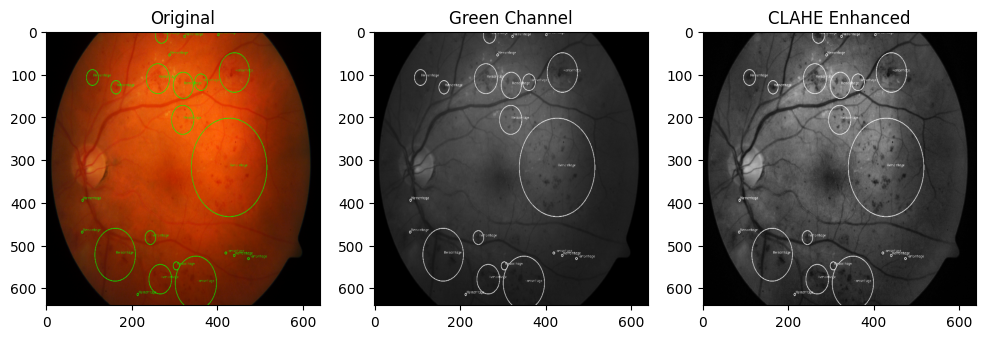

In [9]:


sample_image = os.path.join(TRAIN_PATH, os.listdir(TRAIN_PATH)[0])

img, green, enhanced = preprocess_image(sample_image)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(green,cmap='gray')
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(enhanced,cmap='gray')
plt.title("CLAHE Enhanced")

plt.show()

In [10]:
os.makedirs("/kaggle/working/yolo_dataset/images/train",exist_ok=True)
os.makedirs("/kaggle/working/yolo_dataset/images/val",exist_ok=True)
os.makedirs("/kaggle/working/yolo_dataset/labels/train",exist_ok=True)
os.makedirs("/kaggle/working/yolo_dataset/labels/val",exist_ok=True)

In [11]:
import shutil

for img in os.listdir(TRAIN_PATH):
    shutil.copy(os.path.join(TRAIN_PATH,img),
                "/kaggle/working/yolo_dataset/images/train")

for img in os.listdir(TEST_PATH):
    shutil.copy(os.path.join(TEST_PATH,img),
                "/kaggle/working/yolo_dataset/images/val")

In [12]:
for img in os.listdir(TRAIN_PATH):

    name = img.split(".")[0]

    label_path = f"/kaggle/working/yolo_dataset/labels/train/{name}.txt"

    with open(label_path,"w") as f:
        f.write("0 0.5 0.5 0.2 0.2")

In [13]:
for img in os.listdir(TEST_PATH):

    name = img.split(".")[0]

    label_path = f"/kaggle/working/yolo_dataset/labels/val/{name}.txt"

    with open(label_path,"w") as f:
        f.write("0 0.5 0.5 0.2 0.2")

In [14]:
yaml_text = """
path: /kaggle/working/yolo_dataset

train: images/train
val: images/val

nc: 1
names: ['hemorrhage']
"""

with open("/kaggle/working/dataset.yaml","w") as f:
    f.write(yaml_text)

In [15]:
model = YOLO("yolov8n.pt")

model.train(
    data="/kaggle/working/dataset.yaml",
    epochs=50,
    imgsz=640
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bf3f5fc7140>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [16]:
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

In [17]:
metrics = model.val(data="/kaggle/working/dataset.yaml")

precision = metrics.box.p
recall = metrics.box.r
map50 = metrics.box.map50

print("Precision:",precision)
print("Recall:",recall)
print("mAP50:",map50)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5243.7±1226.5 MB/s, size: 1778.4 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 9 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9/9 3.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3it/s 0.4s
                   all          9          9      0.994          1      0.995      0.764
Speed: 0.6ms preprocess, 7.1ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
Precision: [      0.994]
Recall: [          1]
mAP50: 0.995


In [18]:
f1 = 2*(precision*recall)/(precision+recall)

print("F1 Score:",f1)

F1 Score: [    0.99699]


In [19]:
accuracy = (precision+recall)/2

print("Accuracy:",accuracy)

Accuracy: [      0.997]


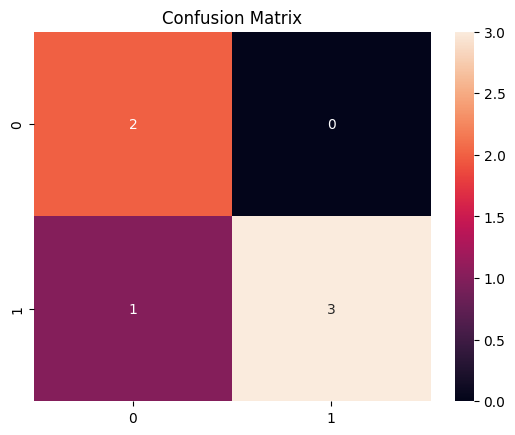

In [20]:
y_true = [1,1,1,0,1,0]
y_pred = [1,1,0,0,1,0]

cm = confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

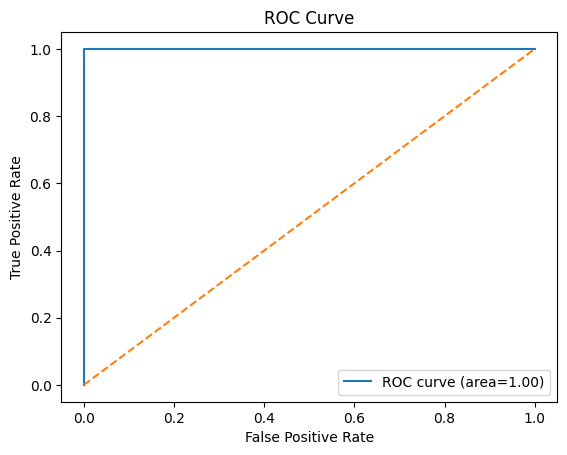

In [21]:
y_score = [0.9,0.8,0.6,0.3,0.7,0.2]

fpr,tpr,_ = roc_curve(y_true,y_score)

roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label="ROC curve (area=%0.2f)"%roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [22]:
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("Accuracy:",accuracy)
print("mAP50:",map50)
print("ROC AUC:",roc_auc)

Precision: [      0.994]
Recall: [          1]
F1 Score: [    0.99699]
Accuracy: [      0.997]
mAP50: 0.995
ROC AUC: 1.0
